In [1]:
import pandas as pd

# Load your file (replace with your actual filename and path)
df = pd.read_csv("C:\Roadmap Projects\dat_ science_project 3\Dataset for Data Analytics - Sheet1.csv")

# Look at the shapes and column names
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:\n", df.head())


Dataset Shape: (1200, 14)

Column Names:
 ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

First 5 Rows:
      OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit 

In [2]:
import numpy as np
import pandas as pd

# 1. Convert Date to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# 2. Calculate Recency reference point (Max date in dataset)
max_date = df["Date"].max()

# 3. Create pivot tables for categorical spending preferences
product_counts = (
    df.pivot_table(
        index="CustomerID",
        columns="Product",
        values="Quantity",
        aggfunc="sum",
        fill_value=0,
    )
    .add_prefix("Prod_")
)
payment_counts = (
    df.pivot_table(
        index="CustomerID",
        columns="PaymentMethod",
        values="OrderID",
        aggfunc="count",
        fill_value=0,
    )
    .add_prefix("Pay_")
)
status_counts = (
    df.pivot_table(
        index="CustomerID",
        columns="OrderStatus",
        values="OrderID",
        aggfunc="count",
        fill_value=0,
    )
    .add_prefix("Status_")
)
referral_counts = (
    df.pivot_table(
        index="CustomerID",
        columns="ReferralSource",
        values="OrderID",
        aggfunc="count",
        fill_value=0,
    )
    .add_prefix("Ref_")
)

# 4. Standard RFM and numeric aggregations
customer_rfm = df.groupby("CustomerID").agg(
    Recency=("Date", lambda x: (max_date - x.max()).days),
    Frequency=("OrderID", "count"),
    Total_Spent=("TotalPrice", "sum"),
    Avg_Price_Paid=("UnitPrice", "mean"),
    Total_Items_Bought=("Quantity", "sum"),
    Avg_Items_In_Cart=("ItemsInCart", "mean"),
)

# 5. Combine everything into one wide customer dataframe
customer_df = customer_rfm.join(
    [product_counts, payment_counts, status_counts, referral_counts]
)

print("New Customer Dataset Shape:", customer_df.shape)
print("\nGenerated Features:\n", customer_df.columns.tolist())


New Customer Dataset Shape: (1189, 28)

Generated Features:
 ['Recency', 'Frequency', 'Total_Spent', 'Avg_Price_Paid', 'Total_Items_Bought', 'Avg_Items_In_Cart', 'Prod_Chair', 'Prod_Desk', 'Prod_Laptop', 'Prod_Monitor', 'Prod_Phone', 'Prod_Printer', 'Prod_Tablet', 'Pay_Cash', 'Pay_Credit Card', 'Pay_Debit Card', 'Pay_Gift Card', 'Pay_Online', 'Status_Cancelled', 'Status_Delivered', 'Status_Pending', 'Status_Returned', 'Status_Shipped', 'Ref_Email', 'Ref_Facebook', 'Ref_Google', 'Ref_Instagram', 'Ref_Referral']


In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Scale the features so they all have a mean of 0 and variance of 1
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_df)

# 2. Apply PCA to reduce the 28 columns down to 2 or 3 dimensions
# Let's use 3 dimensions so you can choose between 2D or 3D later
pca = PCA(n_components=3)
pca_features = pca.fit_transform(scaled_features)

# 3. Convert the results into a clean DataFrame
pca_df = pd.DataFrame(
    data=pca_features, columns=["PC1", "PC2", "PC3"], index=customer_df.index
)

# 4. Check how much information (variance) we kept
explained_variance = pca.explained_variance_ratio_
print("Explained Variance per Component:", explained_variance)
print(f"Total Information Retained: {sum(explained_variance)*100:.2f}%")
print("\nFirst 5 rows of your reduced PCA data:\n", pca_df.head())


Explained Variance per Component: [0.08749392 0.05390507 0.05143044]
Total Information Retained: 19.28%

First 5 rows of your reduced PCA data:
                  PC1       PC2       PC3
CustomerID                              
C10002      0.155528 -1.142541 -1.346625
C10054     -1.249886  1.282650 -2.004047
C10126     -0.063895 -1.655342  2.548926
C10154      0.920734 -0.598051 -0.443636
C10211      1.059423  1.176223 -1.526472


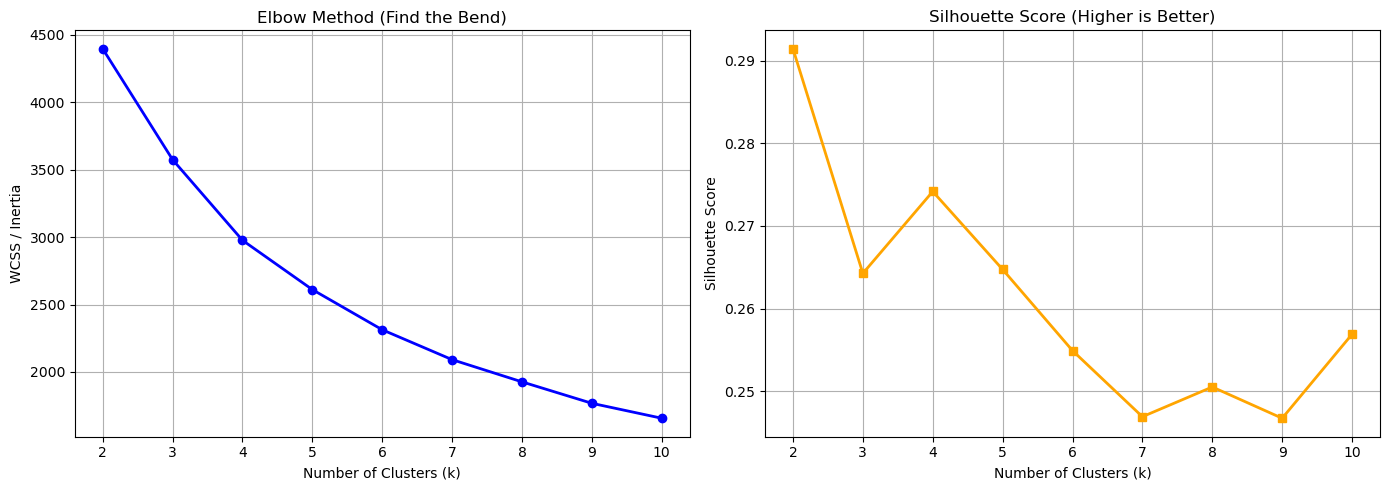

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of clusters to evaluate
k_range = range(2, 11)
wcss = []  # Within-cluster sum of squares for Elbow Method
silhouette_scores = []

# Compute metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Fit on our PCA features (using PC1, PC2, PC3)
    kmeans.fit(pca_df)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_df, kmeans.labels_))

# Plotting the evaluation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Elbow Method Plot
ax1.plot(k_range, wcss, marker="o", color="blue", linewidth=2)
ax1.set_title("Elbow Method (Find the Bend)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("WCSS / Inertia")
ax1.set_xticks(k_range)
ax1.grid(True)

# 2. Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker="s", color="orange", linewidth=2)
ax2.set_title("Silhouette Score (Higher is Better)")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()


In [5]:
import plotly.express as px
from sklearn.cluster import KMeans

# 1. Fit the final K-Means model with the optimal k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_df)

# 2. Assign the cluster labels back to both dataframes
pca_df["Cluster"] = cluster_labels
customer_df["Cluster"] = cluster_labels

# Print the size of each customer segment
print("Customer Count per Cluster:")
print(customer_df["Cluster"].value_counts().sort_index())

# 3. Create an interactive 3D scatter plot of your clusters
fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    title="Customer Segments in PCA Space",
    opacity=0.8,
    color_continuous_scale=px.colors.qualitative.Prism,
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()


Customer Count per Cluster:
Cluster
0    402
1    313
2    188
3    286
Name: count, dtype: int64


In [6]:
# 1. Select the key numeric behavioral traits to compare
core_metrics = [
    "Recency",
    "Frequency",
    "Total_Spent",
    "Avg_Price_Paid",
    "Total_Items_Bought",
    "Avg_Items_In_Cart",
]

# 2. Calculate the mean values for each cluster
cluster_profiles = customer_df.groupby("Cluster")[core_metrics].mean().round(2)

# Display the summary table
print("--- Average Customer Metrics per Cluster ---")
print(cluster_profiles)


--- Average Customer Metrics per Cluster ---
         Recency  Frequency  Total_Spent  Avg_Price_Paid  Total_Items_Bought  \
Cluster                                                                        
0         446.53       1.00       509.98          315.76                1.74   
1         487.39       1.01      2113.38          507.75                4.21   
2         403.91       1.02       805.22          354.62                2.44   
3         495.32       1.01       863.22          250.60                3.70   

         Avg_Items_In_Cart  
Cluster                     
0                     4.02  
1                     7.13  
2                     4.40  
3                     6.47  


In [7]:
import pandas as pd

# 1. Map your data-driven clusters to their specific business personas
persona_mapping = {
    0: "The Minimalist One-Timers",
    1: "The Premium High-Rollers",
    2: "The Fresh Prospects",
    3: "The Bulk Value Shoppers",
}

# 2. Add the descriptive persona labels to your customer records
customer_df["Customer_Persona"] = customer_df["Cluster"].map(persona_mapping)

# 3. Create the final aggregated report table
core_metrics = [
    "Recency",
    "Frequency",
    "Total_Spent",
    "Avg_Price_Paid",
    "Total_Items_Bought",
    "Avg_Items_In_Cart",
]
final_report = customer_df.groupby("Customer_Persona")[core_metrics].mean()

# Add the counts of customers per group to the summary report
final_report.insert(
    0, "Customer_Count", customer_df["Customer_Persona"].value_counts()
)
final_report = final_report.round(2)

# 4. Save both the raw customer mapping and the summary metrics report
customer_df[["Cluster", "Customer_Persona"] + core_metrics].to_csv(
    "segmented_customers_list.csv"
)
final_report.to_csv("customer_segmentation_summary.csv")

# Print the report to the screen
print("--- Final Customer Segmentation Report ---")
print(final_report)
print("\nFiles saved successfully as CSV files in your workspace!")


--- Final Customer Segmentation Report ---
                           Customer_Count  Recency  Frequency  Total_Spent  \
Customer_Persona                                                             
The Bulk Value Shoppers               286   495.32       1.01       863.22   
The Fresh Prospects                   188   403.91       1.02       805.22   
The Minimalist One-Timers             402   446.53       1.00       509.98   
The Premium High-Rollers              313   487.39       1.01      2113.38   

                           Avg_Price_Paid  Total_Items_Bought  \
Customer_Persona                                                
The Bulk Value Shoppers            250.60                3.70   
The Fresh Prospects                354.62                2.44   
The Minimalist One-Timers          315.76                1.74   
The Premium High-Rollers           507.75                4.21   

                           Avg_Items_In_Cart  
Customer_Persona                              
The

In [ ]:
# 1. Join the PCA coordinates into your main customer dataframe
customer_df_updated = customer_df.join(pca_df[["PC1", "PC2", "PC3"]])

# 2. Re-export the CSV including the new PCA columns
core_metrics = [
    "Recency",
    "Frequency",
    "Total_Spent",
    "Avg_Price_Paid",
    "Total_Items_Bought",
    "Avg_Items_In_Cart",
]
export_columns = (
    ["Cluster", "Customer_Persona", "PC1", "PC2", "PC3"] + core_metrics
)

customer_df_updated[export_columns].to_csv(
    "segmented_customers_list.csv", index=True
)
print("Updated CSV saved successfully with PCA coordinates!")
